# 01b - Figuras finales de la EDA

Este notebook se utiliza para generar las versiones definitivas de las figuras de la EDA (ver `notebooks/01_eda_o3.ipynb`) consideradas más relevantes para la memoria (y para la presentación final).

También, de esta manera, se consolidan visualmente los hallazgos principales obtenidos durante la EDA.

Las figuras exploratorias previamente obtenidas se guardaron en `reports/figures/generated/`, mientras que estas figuras finales se guardarán en:

`reports/figures/final/`

## Figuras generadas

Este notebook permite generar las siguientes figuras definitivas para la serie temporal de ozono troposférico (O3):

1. `fig_eda_01_temporal_overview.png`: vista temporal general, media móvil y partición cronológica.
2. `fig_eda_02_missingness_year_month.png`: valores ausentes por año y mes.
3. `fig_eda_03_o3_distribution.png`: distribución global de O3.
4. `fig_eda_04_seasonality_boxplots.png`: estacionalidad mensual, semanal y horaria.
5. `fig_eda_05_month_hour_p90_heatmap.png`: percentil 90 de O3 por mes y hora.
6. `fig_eda_06_acf_lags.png`: autocorrelación de hasta 7 días y retardos.
7. `fig_eda_07_baseline_residuals.png`: distribución y Q-Q plot de residuos de la referencia estacional diaria (`lag_24`).
8. `fig_eda_08_baseline_error_by_hour.png`: error absoluto de la referencia estacional diaria (`lag_24`).
9. `fig_eda_09_interannual_overlay.png`: evolución anual superpuesta de la serie.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from statsmodels.tsa.stattools import acf


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    start = Path.cwd() if start is None else start

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("No se ha podido localizar la raíz del proyecto.")

# Se utiliza la función definida para localizar automáticamente el directorio raíz del repositorio.
PROJECT_ROOT = find_project_root()

# Conjunto de datos procesado que se generará a partir del conjunto de datos bruto.
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "o3_hourly.parquet"

# Directorios donde se guardarán las tablas y figuras generadas durante la EDA.
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_FINAL_DIR = PROJECT_ROOT / "reports" / "figures" / "final"

# Se comprueba, adicionalmente, que los directorios de salida existan.
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset horario base: {PROCESSED_DATA_PATH}")
print(f"Carpeta figuras finales: {FIGURES_FINAL_DIR}")

Raíz del proyecto: c:\trabajo_github
Dataset horario base: c:\trabajo_github\data\processed\o3_hourly.parquet
Carpeta figuras finales: c:\trabajo_github\reports\figures\final


In [3]:
# La EDA parte del conjunto de datos generado por el notebook 00.
# Si este archivo no existe, para obtenerlo, primero deberá ejecutarse notebooks/00_data_preparation_o3.ipynb.
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado data/processed/o3_hourly.parquet. "
        "Ejecuta primero notebooks/00_data_preparation_o3.ipynb."
    )

hourly_df = pd.read_parquet(PROCESSED_DATA_PATH)

# Se asegura que la columna temporal se halle en formato datetime.
hourly_df["timestamp"] = pd.to_datetime(hourly_df["timestamp"])

print(f"Filas: {hourly_df.shape[0]:,}")
print(f"Columnas: {hourly_df.shape[1]:,}")

display(hourly_df.head())
display(hourly_df.tail())

Filas: 52,608
Columnas: 16


,timestamp,o3,station_code,station_name,pollutant_code,pollutant,units,station_type,urban_area,ine_code,municipality,county_code,county_name,altitude,latitude,longitude
0,2020-01-01 00:00:00,22.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
1,2020-01-01 01:00:00,19.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
2,2020-01-01 02:00:00,19.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
3,2020-01-01 03:00:00,6.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
4,2020-01-01 04:00:00,8.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538


,timestamp,o3,station_code,station_name,pollutant_code,pollutant,units,station_type,urban_area,ine_code,municipality,county_code,county_name,altitude,latitude,longitude
52603,2025-12-31 19:00:00,25.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52604,2025-12-31 20:00:00,32.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52605,2025-12-31 21:00:00,36.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52606,2025-12-31 22:00:00,39.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52607,2025-12-31 23:00:00,42.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538


In [4]:
# Comprobación básica del esquema de datos que se espera tenga el conjunto de datos.
# La validación exhaustiva del mismo se efectúa en notebooks/00_data_preparation_o3.ipynb.
required_columns = [
    "timestamp",
    "o3",
    "station_code",
    "station_name",
    "pollutant",
    "units",
]

missing_columns = [
    column for column in required_columns
    if column not in hourly_df.columns
]

if missing_columns:
    raise ValueError(f"Faltan las siguientes columnas esperadas en el conjunto de datos procesado: {missing_columns}")

print(f"Inicio de la serie: {hourly_df['timestamp'].min()}")
print(f"Fin de la serie: {hourly_df['timestamp'].max()}")

display(hourly_df[["timestamp", "o3", "station_name", "pollutant", "units"]].head())

Inicio de la serie: 2020-01-01 00:00:00
Fin de la serie: 2025-12-31 23:00:00


,timestamp,o3,station_name,pollutant,units
0,2020-01-01 00:00:00,22.0,Barcelona (Eixample),O3,µg/m3
1,2020-01-01 01:00:00,19.0,Barcelona (Eixample),O3,µg/m3
2,2020-01-01 02:00:00,19.0,Barcelona (Eixample),O3,µg/m3
3,2020-01-01 03:00:00,6.0,Barcelona (Eixample),O3,µg/m3
4,2020-01-01 04:00:00,8.0,Barcelona (Eixample),O3,µg/m3


In [ ]:
# Configuración común para las figuras finales.
# Se define un estilo sencillo y homogéneo en línea con el ya utilizado,
# que se estima adecuado para la memoria y la presentación.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.titlesize": 13,
    }
)

MONTH_LABELS = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}

WEEKDAY_LABELS = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo",
]

BLOCK_BOUNDARIES = {
    "Calibración": pd.Timestamp("2023-01-01"),
    "Validación": pd.Timestamp("2024-01-01"),
    "Prueba": pd.Timestamp("2025-01-01"),
}

MODELING_END = pd.Timestamp("2024-12-31 23:00:00")

def save_final_figure(fig: plt.Figure, filename: str) -> Path:
    """Guarda una figura final en reports/figures/final."""
    output_path = FIGURES_FINAL_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Figura guardada en: {output_path}")
    return output_path

def add_panel_label(ax: plt.Axes, label: str) -> None:
    """Añade una etiqueta de panel dentro de una figura compuesta."""
    ax.text(
        0.01,
        0.98,
        label,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontweight="bold",
        fontsize=11,
    )

In [ ]:
# Se añaden variables temporales para facilitar los análisis agrupados.
eda_df = hourly_df.copy()

eda_df["timestamp"] = pd.to_datetime(eda_df["timestamp"])
eda_df["date"] = eda_df["timestamp"].dt.floor("D")
eda_df["year"] = eda_df["timestamp"].dt.year
eda_df["month"] = eda_df["timestamp"].dt.month
eda_df["hour"] = eda_df["timestamp"].dt.hour
eda_df["day_of_week"] = eda_df["timestamp"].dt.dayofweek

observed_df = eda_df.dropna(subset=["o3"]).copy()

# Periodo previo al conjunto de prueba. Este lapso temporal se utilizará para construir las figuras
# que contribuyan a tomar decisiones acerca del modelado.
modeling_df = eda_df[eda_df["timestamp"] <= MODELING_END].copy()
observed_modeling_df = modeling_df.dropna(subset=["o3"]).copy()

Observaciones totales:                 52,608
Observaciones con O3 observado:         50,942
Observaciones previas al test:          43,848
Observaciones previas al test con O3:   42,561


## Figura 1 - Vista temporal general, media móvil y partición cronológica de la serie

Esta figura combina la serie horaria original del ozono troposférico (O3), la media diaria, la media móvil de 30 días y las fronteras de la partición cronológica.

Su función es presentar visualmente a los lectores la variabilidad real de la serie y justificar el uso de una partición temporal estricta.

Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_01_temporal_overview.png


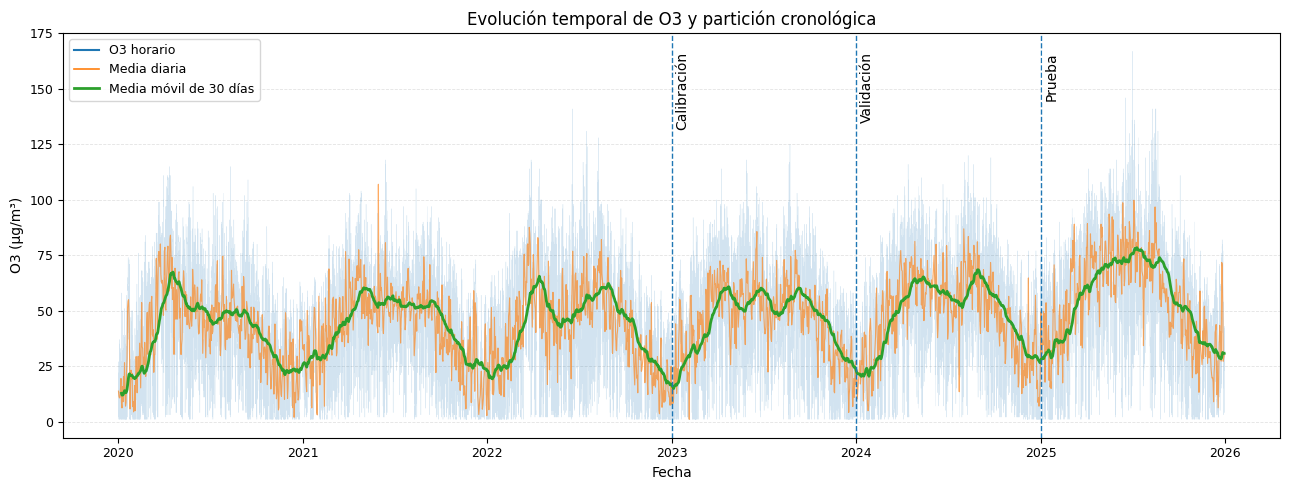

In [ ]:
from matplotlib.lines import Line2D

temporal_df = eda_df[["timestamp", "date", "o3"]].copy()

daily_o3 = (
    temporal_df
    .dropna(subset=["o3"])
    .groupby("date")["o3"]
    .mean()
    .to_frame(name="daily_mean_o3")
    .sort_index()
)

daily_o3["rolling_30d_mean_o3"] = daily_o3["daily_mean_o3"].rolling(
    window=30,
    min_periods=7,
).mean()

fig, ax = plt.subplots(figsize=(13, 5))

# Se definen los colores para cada componente de la gráfica
hourly_color = "tab:blue"
daily_color = "tab:orange"
rolling_color = "tab:green"
boundary_color = "tab:blue"

# Se dibuja la serie horaria de O3 con cierta transparencia para que la media diaria
# y móvil también sean visibles y fáciles de interpretar.
ax.plot(
    temporal_df["timestamp"],
    temporal_df["o3"],
    linewidth=0.25,
    alpha=0.20,
    color=hourly_color,
)

# Se dibuja la media diaria de O3.
ax.plot(
    daily_o3.index,
    daily_o3["daily_mean_o3"],
    linewidth=0.8,
    alpha=0.65,
    color=daily_color,
)

# Se dibuja la media móvil
ax.plot(
    daily_o3.index,
    daily_o3["rolling_30d_mean_o3"],
    linewidth=2.0,
    color=rolling_color,
)

# Se añaden las fronteras verticales entre bloques cronológicos.
upper_y = ax.get_ylim()[1]

for label, boundary in BLOCK_BOUNDARIES.items():
    ax.axvline(
        boundary,
        linestyle="--",
        linewidth=1,
        color=boundary_color,
    )
    ax.text(
        boundary + pd.Timedelta(days=8),
        upper_y * .95,
        label,
        rotation=90,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5,
        ),
    )

ax.set_title("Evolución de la concentración horaria de O3 y partición cronológica")
ax.set_xlabel("Fecha")
ax.set_ylabel("O3 (µg/m³)")
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

# Se dibuja la leyenda de la gráfica
legend_handles = [
    Line2D([0], [0], color=hourly_color, linewidth=1.5, label="O3 horario"),
    Line2D([0], [0], color=daily_color, linewidth=1.2, label="Media diaria"),
    Line2D([0], [0], color=rolling_color, linewidth=2.0, label="Media móvil de 30 días"),
]

ax.legend(handles=legend_handles, loc="upper left")

fig.tight_layout()

save_final_figure(fig, "fig_eda_01_temporal_overview.png")

plt.show()

## Figura 2 - Valores ausentes de la serie por año y mes

Este mapa de calor resume la distribución temporal de los valores ausentes de O3.

Su función es documentar los huecos en la serie y la decisión de no imputarlos indiscriminadamente, ya que, como se aprecia, en general la continuidad de las medidas es adecuada y no se desea introducir sesgos durante el entrenamiento o la evaluación.

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
year,,,,,,,,,,,,
2020,0.54,0.72,0.81,1.53,0.27,0.69,0.81,0.27,0.42,0.94,8.19,0.94
2021,9.27,3.42,1.08,4.17,10.75,0.56,5.91,0.54,0.42,0.54,0.83,0.94
2022,0.27,0.30,0.81,13.33,10.22,2.08,0.54,0.54,7.08,0.54,16.39,1.34
2023,0.54,1.19,0.81,0.83,1.08,7.22,2.02,0.94,0.14,0.81,1.11,4.30
2024,17.20,0.57,0.40,4.72,2.42,12.22,4.30,0.67,1.25,1.08,1.67,0.81
2025,1.08,1.34,5.51,2.36,8.20,4.44,13.44,1.88,1.25,0.81,10.42,0.94


Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_02_missingness_year_month.png


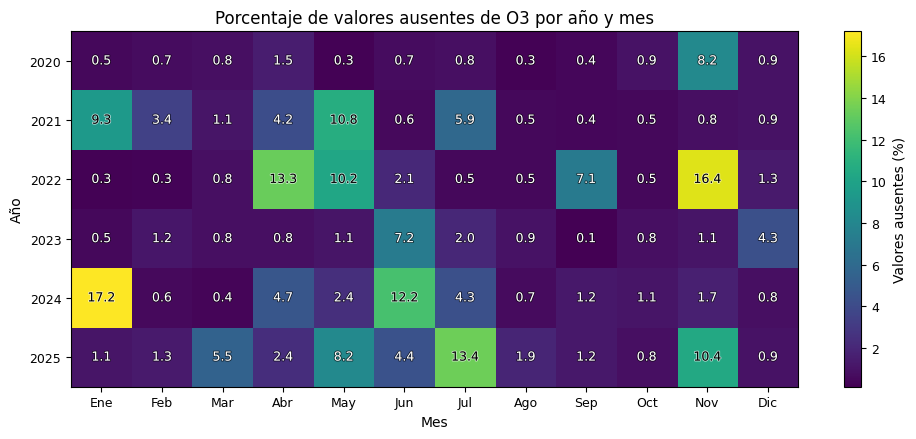

In [ ]:
from matplotlib import patheffects as pe

missing_by_year_month = (
    eda_df.groupby(["year", "month"])
    .agg(
        hourly_records=("timestamp", "size"),
        missing_o3_percentage=("o3", lambda values: values.isna().mean() * 100),
    )
    .reset_index()
)

missing_matrix = (
    missing_by_year_month
    .pivot(index="year", columns="month", values="missing_o3_percentage")
    .reindex(index=sorted(eda_df["year"].unique()), columns=range(1, 13))
)

missing_matrix.columns = [MONTH_LABELS[month] for month in missing_matrix.columns]

display(missing_matrix.round(2))

fig, ax = plt.subplots(figsize=(10, 4.5))

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(
    vmin=np.nanmin(missing_matrix.values),
    vmax=np.nanmax(missing_matrix.values),
)

image = ax.imshow(
    missing_matrix.values,
    aspect="auto",
    cmap=cmap,
    norm=norm,
)

ax.set_title("Porcentaje de valores ausentes de O3 por año y mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")

ax.set_xticks(np.arange(missing_matrix.shape[1]))
ax.set_xticklabels(missing_matrix.columns)

ax.set_yticks(np.arange(missing_matrix.shape[0]))
ax.set_yticklabels(missing_matrix.index)

for row_idx in range(missing_matrix.shape[0]):
    for col_idx in range(missing_matrix.shape[1]):
        value = missing_matrix.iat[row_idx, col_idx]

        if pd.isna(value):
            continue

        rgba = cmap(norm(value))
        red, green, blue, _ = rgba
        luminance = 0.299 * red + 0.587 * green + 0.114 * blue

        text_color = "white" if luminance < 0.45 else "black"
        stroke_color = "black" if text_color == "white" else "white"

        ax.text(
            col_idx,
            row_idx,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
            path_effects=[
                pe.withStroke(
                    linewidth=1.2,
                    foreground=stroke_color,
                    alpha=0.65,
                )
            ],
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Valores ausentes (%)")

fig.tight_layout()

save_final_figure(fig, "fig_eda_02_missingness_year_month.png")

plt.show()

## Figura 3 - Distribución global de O3

Esta figura muestra la distribución global de las concentraciones horarias observadas de O3.

Se añaden líneas de referencia para la mediana, el percentil 95 y el percentil 99.

Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_03_o3_distribution.png


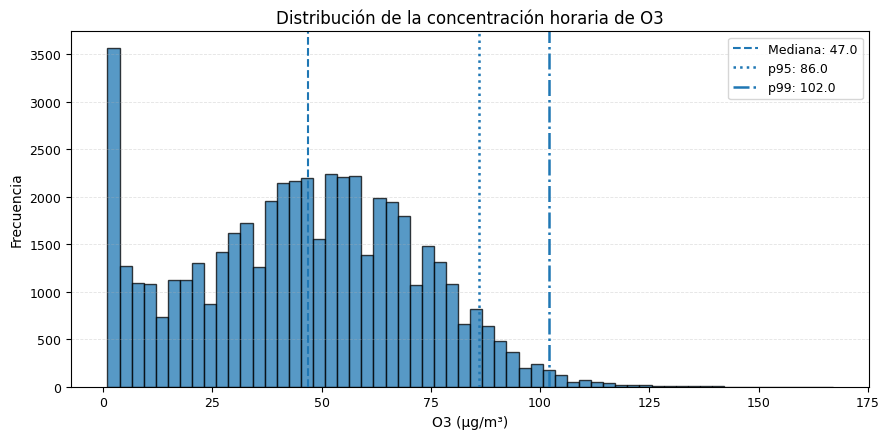

In [9]:
observed_o3 = observed_df["o3"]

median_o3 = observed_o3.median()
p95_o3 = observed_o3.quantile(0.95)
p99_o3 = observed_o3.quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(
    observed_o3,
    bins=60,
    edgecolor="black",
    alpha=0.75,
)

ax.axvline(median_o3, linestyle="--", linewidth=1.5, label=f"Mediana: {median_o3:.1f}")
ax.axvline(p95_o3, linestyle=":", linewidth=1.8, label=f"p95: {p95_o3:.1f}")
ax.axvline(p99_o3, linestyle="-.", linewidth=1.8, label=f"p99: {p99_o3:.1f}")

ax.set_title("Distribución de la concentración horaria de O3")
ax.set_xlabel("O3 (µg/m³)")
ax.set_ylabel("Frecuencia")
ax.legend()

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

fig.tight_layout()

save_final_figure(fig, "fig_eda_03_o3_distribution.png")

plt.show()

## Figura 4 - Estacionalidad mensual, semanal y horaria

Esta figura, de carácter compuesto, resume la estacionalidad mensual, semanal y horaria de la serie temporal de O3.

Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_04_seasonality_boxplots.png


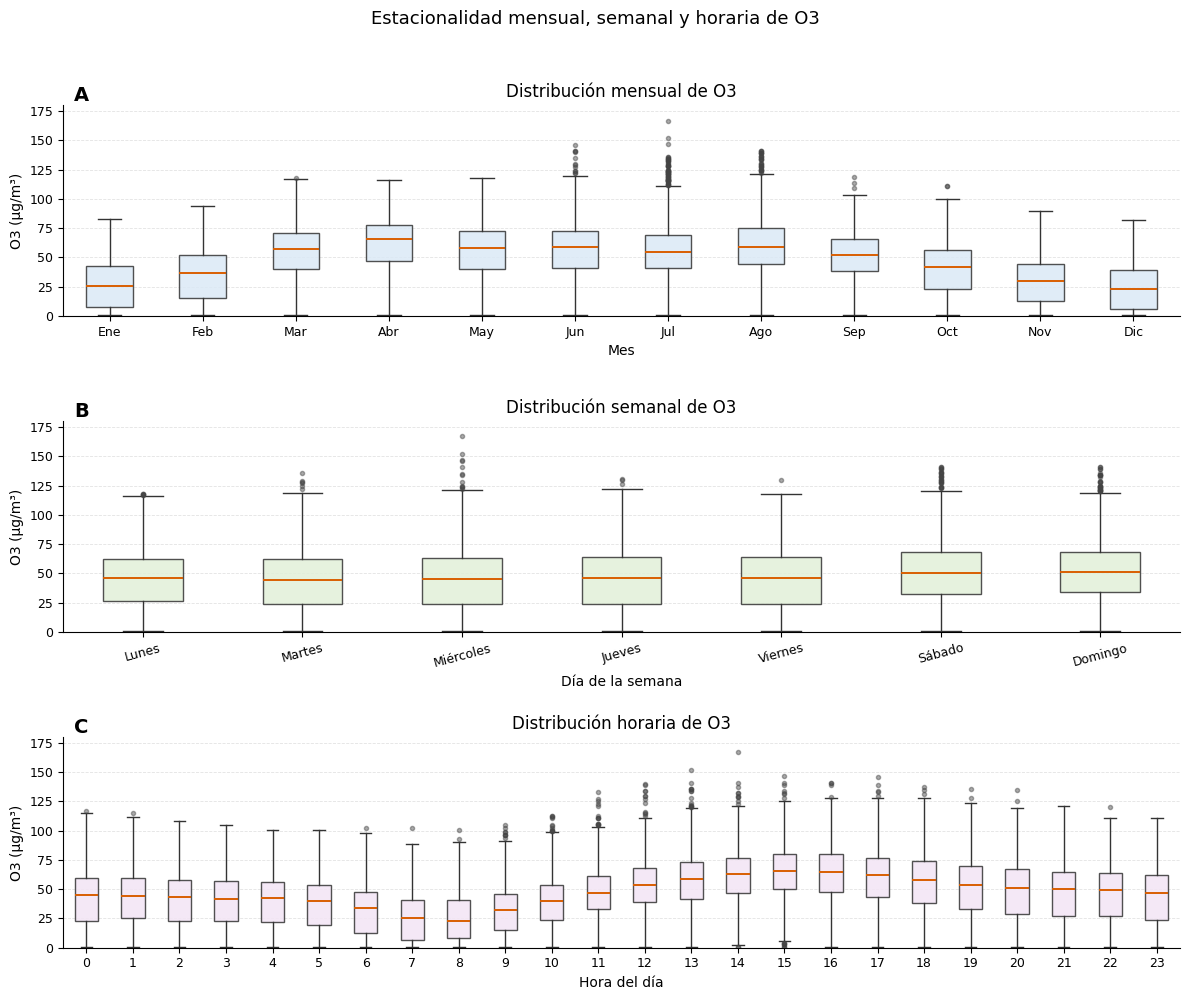

In [ ]:
monthly_boxplot_data = [
    observed_df.loc[observed_df["month"] == month, "o3"].to_numpy()
    for month in range(1, 13)
]

weekday_boxplot_data = [
    observed_df.loc[observed_df["day_of_week"] == day, "o3"].to_numpy()
    for day in range(7)
]

hourly_boxplot_data = [
    observed_df.loc[observed_df["hour"] == hour, "o3"].to_numpy()
    for hour in range(24)
]

def add_panel_label(ax: plt.Axes, label: str) -> None:
    ax.text(
        0.01,
        1.09,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
    )


def draw_styled_boxplot(
    ax: plt.Axes,
    data: list[np.ndarray],
    labels: list[str],
    title: str,
    xlabel: str,
    facecolor: str,
) -> None:
    """Draw a clean boxplot for the final EDA figures."""
    ax.boxplot(
        data,
        tick_labels=labels,
        showfliers=True,
        patch_artist=True,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "#333333",
            "linewidth": 1.0,
            "alpha": 0.85,
        },
        medianprops={
            "color": "#d95f02",
            "linewidth": 1.4,
        },
        whiskerprops={
            "color": "#333333",
            "linewidth": 1.0,
        },
        capprops={
            "color": "#333333",
            "linewidth": 1.0,
        },
        flierprops={
            "marker": "o",
            "markersize": 3,
            "markerfacecolor": "#444444",
            "markeredgecolor": "#444444",
            "alpha": 0.45,
        },
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("O3 (µg/m³)")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=True)

max_o3 = observed_df["o3"].max()
upper_y = np.ceil(max_o3 * 1.05 / 10) * 10
upper_y = max(upper_y, 120)

# Panel A: Estacionalidad mensual.
draw_styled_boxplot(
    ax=axes[0],
    data=monthly_boxplot_data,
    labels=[MONTH_LABELS[month] for month in range(1, 13)],
    title="Distribución mensual de O3",
    xlabel="Mes",
    facecolor="#dbe9f6",
)
add_panel_label(axes[0], "A")

# Panel B: Estacionalidad semanal.
draw_styled_boxplot(
    ax=axes[1],
    data=weekday_boxplot_data,
    labels=WEEKDAY_LABELS,
    title="Distribución semanal de O3",
    xlabel="Día de la semana",
    facecolor="#e2f0d9",
)
axes[1].tick_params(axis="x", rotation=15)
add_panel_label(axes[1], "B")

# Panel C: Estacionalidad horaria.
draw_styled_boxplot(
    ax=axes[2],
    data=hourly_boxplot_data,
    labels=[str(hour) for hour in range(24)],
    title="Distribución horaria de O3",
    xlabel="Hora del día",
    facecolor="#f3e5f5",
)
add_panel_label(axes[2], "C")

for ax in axes:
    ax.set_ylim(0, upper_y)

fig.suptitle("Estacionalidad mensual, semanal y horaria de O3", y=0.995)

fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.subplots_adjust(hspace=0.5)

save_final_figure(fig, "fig_eda_04_seasonality_boxplots.png")

plt.show()

## Figura 5 - Percentil 90 de O3 por mes y hora

Esta figura muestra cómo interactúan el ciclo anual y el ciclo diario del ozono troposférico cuando se dan altas concentraciones de este.

Se usa el periodo previo al conjunto de prueba para evitar que el año 2025 influya en decisiones respecto al modelado.

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Ene,52.0,54.0,54.3,54.9,56.6,52.4,50.0,44.0,37.5,43.0,46.0,46.6,50.8,53.7,57.0,58.0,54.5,51.4,47.8,46.4,46.8,49.4,51.6,50.4
Feb,59.0,60.0,58.0,62.0,60.0,58.0,51.0,45.0,39.0,43.1,52.0,59.5,62.0,67.2,72.3,73.0,76.0,73.0,62.0,60.0,58.0,57.0,55.9,54.9
Mar,79.0,80.0,80.6,78.6,79.2,77.6,69.6,62.6,60.2,64.6,70.9,76.0,80.4,85.0,89.0,88.0,89.4,86.2,83.6,81.2,80.0,79.0,77.6,76.0
Abr,81.0,82.0,80.4,80.8,76.0,74.0,69.9,66.0,61.0,68.0,71.0,74.0,88.0,94.2,96.0,100.0,100.0,99.4,97.0,92.0,86.0,86.7,85.7,85.0
May,73.2,71.0,67.3,67.0,65.0,64.0,60.0,52.0,54.0,61.0,66.8,77.0,79.0,82.8,88.0,93.3,91.0,89.4,85.2,85.0,80.0,77.2,78.0,75.3
Jun,74.0,71.7,71.0,66.7,66.7,61.0,56.7,54.0,58.7,61.0,69.6,76.0,82.0,88.0,88.0,93.7,88.7,89.0,85.5,83.5,80.0,77.5,76.6,76.0
Jul,67.0,66.0,65.0,61.0,59.9,59.0,53.8,50.0,53.0,60.0,68.6,76.0,82.0,89.5,89.4,89.1,87.0,87.8,84.8,77.0,73.0,72.8,71.0,70.9
Ago,75.0,74.6,72.0,71.6,68.6,67.0,61.4,55.2,59.0,67.8,74.1,81.0,88.0,92.0,96.8,97.7,95.0,92.6,88.6,85.0,79.0,79.6,80.0,78.0
Sep,70.3,70.3,68.0,66.0,63.0,60.3,55.0,50.3,49.3,54.2,64.6,71.0,76.0,83.0,85.4,90.0,89.3,87.3,84.0,77.0,73.0,72.0,73.3,72.0
Oct,60.0,60.6,60.1,60.0,60.6,56.2,54.8,46.6,42.2,42.7,52.0,58.0,65.1,69.0,73.0,79.0,79.7,74.6,68.6,65.6,63.0,62.0,62.6,60.0


Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_05_month_hour_p90_heatmap.png


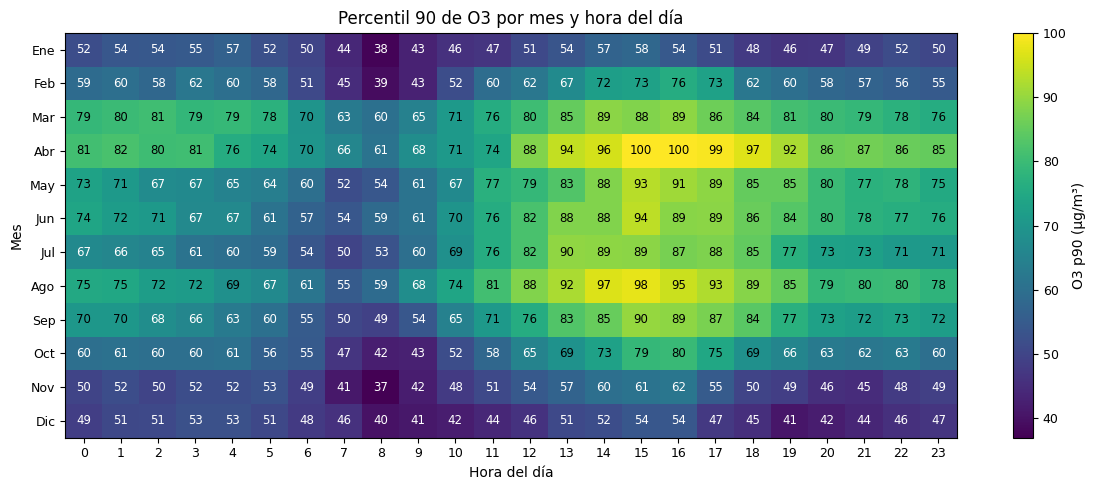

In [ ]:
month_hour_p90 = (
    observed_modeling_df
    .pivot_table(
        index="month",
        columns="hour",
        values="o3",
        aggfunc=lambda values: values.quantile(0.90),
    )
    .reindex(index=range(1, 13), columns=range(24))
)

month_hour_p90.index = [MONTH_LABELS[month] for month in month_hour_p90.index]

display(month_hour_p90.round(2))

fig, ax = plt.subplots(figsize=(12, 5))

image = ax.imshow(month_hour_p90.values, aspect="auto")

ax.set_title("Percentil 90 de O3 por mes y hora del día")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Mes")

ax.set_xticks(np.arange(24))
ax.set_xticklabels(range(24))

ax.set_yticks(np.arange(12))
ax.set_yticklabels(month_hour_p90.index)

for row_idx in range(month_hour_p90.shape[0]):
    for col_idx in range(month_hour_p90.shape[1]):
        value = month_hour_p90.iat[row_idx, col_idx]

        if pd.isna(value):
            continue

        normalized_value = image.norm(value)
        text_color = "white" if normalized_value < 0.5 else "black"

        ax.text(
            col_idx,
            row_idx,
            f"{value:.0f}",
            ha="center",
            va="center",
            fontsize=8.5,
            color=text_color,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("O3 p90 (µg/m³)")

fig.tight_layout()

save_final_figure(fig, "fig_eda_05_month_hour_p90_heatmap.png")

plt.show()

## Figura 6 - Autocorrelación de O3 para retardos de hasta 168 horas (7 días)

Esta figura muestra hasta qué punto cada valor horario de O3 se parece a valores observados anteriormente, desde 1 hora hasta 168 horas antes.

El retardo de 24 horas permite analizar la repetición diaria; por su parte, el retardo de 168 horas permite observar una posible repetición semanal.

Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_06_acf_lags.png


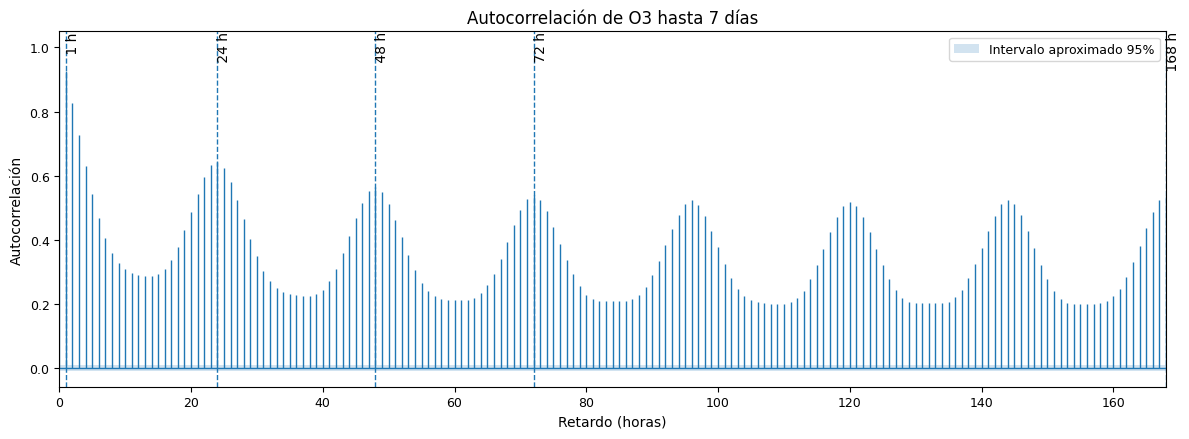

In [ ]:
# A continuación, se observará la correlación del O3 actual con sus valores en horas anteriores.
# Para calcular esta correlación correctamente, la serie deberá tener una observación en cada hora;
# como hay algunos valores de O3 ausentes, se rellenarán temporalmente, pero solo para este análisis.
o3_series_for_acf = (
    eda_df.set_index("timestamp")["o3"]
    .sort_index()
    .asfreq("h")
    .interpolate(limit_direction="both")
)

# Se calcula la autocorrelación hasta 7 días atrás.
max_lag = 24 * 7
acf_values = acf(o3_series_for_acf, nlags=max_lag, fft=True)

lags = np.arange(len(acf_values))
confidence_band = 1.96 / np.sqrt(len(o3_series_for_acf))

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.vlines(lags, 0, acf_values, linewidth=1)
ax.axhline(0, linewidth=1)
ax.axhspan(-confidence_band, confidence_band, alpha=0.20, label="Intervalo aproximado 95%")

for selected_lag in [1, 24, 48, 72, 168]:
    ax.axvline(selected_lag, linestyle="--", linewidth=1)
    ax.text(
        selected_lag,
        ax.get_ylim()[1],
        f" {selected_lag} h",
        rotation=90,
        va="top",
        ha="left",
    )

ax.set_title("Autocorrelación de O3 hasta 7 días")
ax.set_xlabel("Retardo (horas)")
ax.set_ylabel("Autocorrelación")
ax.set_xlim(0, max_lag)
ax.legend(loc="upper right")

fig.tight_layout()

save_final_figure(fig, "fig_eda_06_acf_lags.png")

plt.show()

## Figura 7 - Diagnóstico de los residuos de la referencia estacional diaria

Esta figura compara la distribución de los residuos de la referencia estacional diaria (`lag_24`) con una referencia normal ajustada y muestra también un gráfico Q-Q.

El objetivo es comprobar si, para capturar la verdad fundamental, sería razonable utilizar un intervalo fijo basado únicamente en la normalidad y la desviación típica. Si los residuos se alejan de la normalidad, especialmente en los extremos, se reforzaría la conveniencia de utilizar intervalos de predicción calibrados mediante predicción conforme.

Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_07_baseline_residuals.png


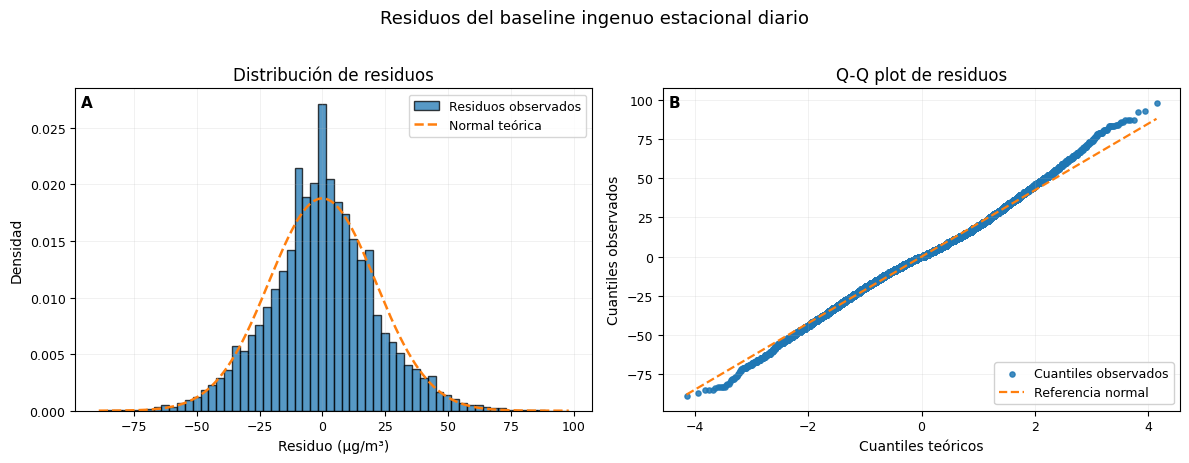

In [ ]:
baseline_df = (
    modeling_df[["timestamp", "o3"]]
    .set_index("timestamp")
    .sort_index()
    .asfreq("h")
)

baseline_df["prediction_lag_24"] = baseline_df["o3"].shift(24)
baseline_df["residual_lag_24"] = baseline_df["o3"] - baseline_df["prediction_lag_24"]

residuals_lag_24 = baseline_df["residual_lag_24"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

residuals_color = "tab:blue"

axes[0].hist(
    residuals_lag_24,
    bins=60,
    density=True,
    edgecolor="black",
    color=residuals_color,
    alpha=0.75,
    label="Residuos observados",
)

x_values = np.linspace(
    residuals_lag_24.min(),
    residuals_lag_24.max(),
    500,
)

normal_density = stats.norm.pdf(
    x_values,
    loc=residuals_lag_24.mean(),
    scale=residuals_lag_24.std(),
)

axes[0].plot(
    x_values,
    normal_density,
    linestyle="--",
    linewidth=1.8,
    color="tab:orange",
    label="Normal ajustada",
)

axes[0].set_title("Distribución de residuos")
axes[0].set_xlabel("Residuo (µg/m³)")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(alpha=0.20, linewidth=0.6)
add_panel_label(axes[0], "A")

theoretical_quantiles, observed_quantiles = stats.probplot(
    residuals_lag_24,
    dist="norm",
    fit=False,
)

slope, intercept, _ = stats.probplot(
    residuals_lag_24,
    dist="norm",
    fit=True,
)[1]

axes[1].scatter(
    theoretical_quantiles,
    observed_quantiles,
    s=14,
    color=residuals_color,
    alpha=0.85,
    label="Cuantiles observados",
)

x_line = np.array([
    theoretical_quantiles.min(),
    theoretical_quantiles.max(),
])

axes[1].plot(
    x_line,
    slope * x_line + intercept,
    color="tab:orange",
    linestyle="--",
    linewidth=1.6,
    label="Referencia normal",
)

axes[1].legend(
    loc="lower right",
    frameon=True,
    framealpha=0.90,
)

axes[1].set_title("Q-Q plot de residuos")
axes[1].set_xlabel("Cuantiles teóricos")
axes[1].set_ylabel("Cuantiles observados")
axes[1].grid(alpha=0.20, linewidth=0.6)
add_panel_label(axes[1], "B")

fig.suptitle("Residuos del baseline ingenuo estacional diario", y=1.02)
fig.tight_layout()

save_final_figure(fig, "fig_eda_07_baseline_residuals.png")

plt.show()

## Figura 8 - Error absoluto de la referencia estacional diaria

Esta figura muestra si el error absoluto de la referencia estacional diaria cambia a lo largo del día.

Su función es ilustrar la heterocedasticidad temporal.

,mean_absolute_residual,median_absolute_residual,p95_absolute_residual
hour,,,
0,18.81,15.0,49.00
1,18.90,15.0,49.00
2,19.14,15.0,51.00
3,19.08,15.0,51.00
4,18.70,14.0,50.00
5,18.76,15.0,50.00
6,18.29,15.0,48.75
7,16.47,13.0,45.00
8,15.46,12.0,44.00


Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_08_baseline_error_by_hour.png


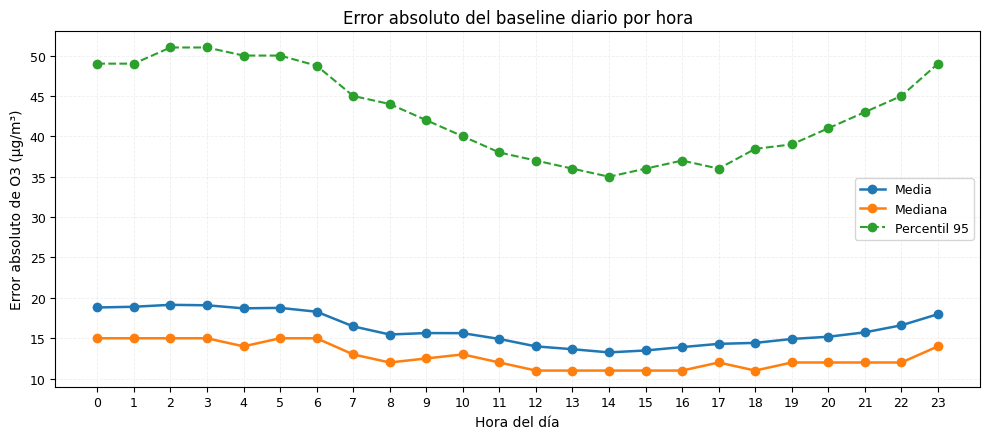

In [ ]:
baseline_error_df = baseline_df.dropna(
    subset=["o3", "prediction_lag_24", "residual_lag_24"]
).reset_index()

baseline_error_df["hour"] = baseline_error_df["timestamp"].dt.hour
baseline_error_df["absolute_residual_lag_24"] = baseline_error_df["residual_lag_24"].abs()

baseline_error_by_hour = (
    baseline_error_df.groupby("hour")["absolute_residual_lag_24"]
    .agg(
        mean_absolute_residual="mean",
        median_absolute_residual="median",
        p95_absolute_residual=lambda values: values.quantile(0.95),
    )
)

display(baseline_error_by_hour.round(2))

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(
    baseline_error_by_hour.index,
    baseline_error_by_hour["mean_absolute_residual"],
    marker="o",
    linewidth=1.8,
    label="Media",
)

ax.plot(
    baseline_error_by_hour.index,
    baseline_error_by_hour["median_absolute_residual"],
    marker="o",
    linewidth=1.8,
    label="Mediana",
)

ax.plot(
    baseline_error_by_hour.index,
    baseline_error_by_hour["p95_absolute_residual"],
    marker="o",
    linewidth=1.5,
    linestyle="--",
    label="Percentil 95",
)

ax.set_title("Error absoluto de la referencia estacional diaria por hora")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Error absoluto de O3 (µg/m³)")
ax.set_xticks(range(24))
ax.legend()

ax.grid(linestyle="--", alpha=0.20, linewidth=0.6)

fig.tight_layout()

save_final_figure(fig, "fig_eda_08_baseline_error_by_hour.png")

plt.show()

## Figura 9 - Perfil anual suavizado del O3

Esta figura compara, de manera superpuesta, la evolución suavizada de la serie para cada año.

El objetivo es estudiar el comportamiento del año 2020 respecto a los posteriores.

,year,date,daily_mean_o3,day_of_year,rolling_14d_mean_o3
0,2020,2020-01-01,13.708333,1,12.732143
1,2020,2020-01-02,11.291667,2,11.906250
2,2020,2020-01-03,10.625000,3,12.333333
3,2020,2020-01-04,11.041667,4,11.991667
4,2020,2020-01-05,14.666667,5,12.734848


Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_09_interannual_overlay.png


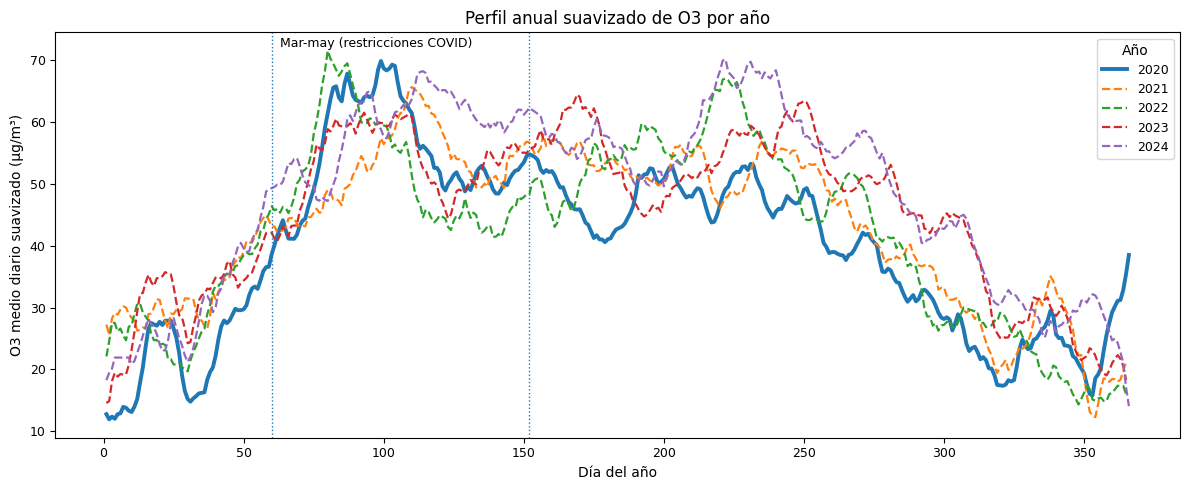

In [ ]:
regime_df = (
    eda_df[eda_df["year"].between(2020, 2024)]
    .dropna(subset=["o3"])
    .copy()
)

daily_profile_by_year = (
    regime_df.groupby(["year", "date"])
    .agg(daily_mean_o3=("o3", "mean"))
    .reset_index()
)

daily_profile_by_year["day_of_year"] = daily_profile_by_year["date"].dt.dayofyear

daily_profile_by_year["rolling_14d_mean_o3"] = (
    daily_profile_by_year
    .groupby("year")["daily_mean_o3"]
    .transform(lambda values: values.rolling(window=14, center=True, min_periods=5).mean())
)

comparison_years = sorted(daily_profile_by_year["year"].unique())

display(daily_profile_by_year.head())

fig, ax = plt.subplots(figsize=(12, 5))

for year in comparison_years:
    year_data = daily_profile_by_year[daily_profile_by_year["year"] == year]

    linewidth = 2.8 if year == 2020 else 1.6
    linestyle = "-" if year == 2020 else "--"

    ax.plot(
        year_data["day_of_year"],
        year_data["rolling_14d_mean_o3"],
        linewidth=linewidth,
        linestyle=linestyle,
        label=str(year),
    )

ax.axvline(60, linestyle=":", linewidth=1)
ax.axvline(152, linestyle=":", linewidth=1)
upper_y = ax.get_ylim()[1]

ax.text(
    63,
    upper_y * 0.989,
    "Mar-may (restricciones COVID)",
    va="top",
    ha="left",
    fontsize=9,
)

ax.set_title("Perfil anual suavizado de O3 por año")
ax.set_xlabel("Día del año")
ax.set_ylabel("O3 medio diario suavizado (µg/m³)")
ax.legend(title="Año")

fig.tight_layout()

save_final_figure(fig, "fig_eda_09_interannual_overlay.png")

plt.show()

## Catálogo de figuras definitivas

La siguiente tabla contiene un resumen de las figuras generadas y el mensaje principal que se espera trasladar en la memoria.

In [ ]:
final_figures_catalog = pd.DataFrame(
    [
        {
            "figure_id": "EDA-01",
            "filename": "fig_eda_01_temporal_overview.png",
            "title": "Evolución temporal de O3 y partición cronológica",
            "main_message": "La serie presenta variabilidad horaria y una evolución temporal que justifica la partición cronológica.",
        },
        {
            "figure_id": "EDA-02",
            "filename": "fig_eda_02_missingness_year_month.png",
            "title": "Valores ausentes de O3 por año y mes",
            "main_message": "Los valores ausentes son moderados, pero no completamente uniformes en el tiempo.",
        },
        {
            "figure_id": "EDA-03",
            "filename": "fig_eda_03_o3_distribution.png",
            "title": "Distribución global de O3",
            "main_message": "La distribución muestra que se alcanzan valores de cierta importancia pero no excesivamente elevados.",
        },
        {
            "figure_id": "EDA-04",
            "filename": "fig_eda_04_seasonality_boxplots.png",
            "title": "Estacionalidad mensual, semanal y horaria",
            "main_message": "La serie presenta patrones estacionales que justifica el uso de variables temporales.",
        },
        {
            "figure_id": "EDA-05",
            "filename": "fig_eda_05_month_hour_p90_heatmap.png",
            "title": "Percentil 90 de O3 por mes y hora",
            "main_message": "Se muestra la importancia que la combinación entre mes y hora del día tiene a la hora de predecir una concentración elevada de O3.",
        },
        {
            "figure_id": "EDA-06",
            "filename": "fig_eda_06_acf_lags.png",
            "title": "Autocorrelación de O3 para retardos de hasta 168 horas (7 días)",
            "main_message": "La autocorrelación justifica lautilización de retardos cortos, diarios y semanales.",
        },
        {
            "figure_id": "EDA-07",
            "filename": "fig_eda_07_baseline_residuals.png",
            "title": "Diagnóstico de los residuos de la referencia estacional diaria",
            "main_message": "Los residuos muestran desviaciones respecto a la normalidad y motivan el uso de intervalos de predicción.",
        },
        {
            "figure_id": "EDA-08",
            "filename": "fig_eda_08_baseline_error_by_hour.png",
            "title": "Error absoluto de la referencia estacional diaria",
            "main_message": "El error varía según la hora, lo que sugiere heterocedasticidad temporal.",
        },
        {
            "figure_id": "EDA-09",
            "filename": "fig_eda_09_interannual_overlay.png",
            "title": "Perfil anual suavizado del O3",
            "main_message": "La comparación interanual permite estudiar la potencial singularidad del año 2020.",
        },
    ]
)

display(final_figures_catalog)

final_figures_catalog.to_csv(
    TABLES_DIR / "eda_final_figures_catalog.csv",
    index=False,
)

print(f"Catálogo guardado en: {TABLES_DIR / 'eda_final_figures_catalog.csv'}")

,figure_id,filename,title,main_message,suggested_memory_section
0,EDA-01,fig_eda_01_temporal_overview.png,Evolución temporal de O3 y partición cronológica,La serie presenta variabilidad horaria y una e...,Datos y evolución temporal
1,EDA-02,fig_eda_02_missingness_year_month.png,Valores ausentes de O3 por año y mes,"Los valores ausentes son moderados, pero no co...",Calidad del dato
2,EDA-03,fig_eda_03_o3_distribution.png,Distribución global de O3,La distribución muestra valores altos que se d...,Distribución general
3,EDA-04,fig_eda_04_seasonality_boxplots.png,"Estacionalidad mensual, semanal y horaria",La serie presenta patrones estacionales que ju...,Estacionalidad
4,EDA-05,fig_eda_05_month_hour_p90_heatmap.png,Percentil 90 de O3 por mes y hora,Los valores altos dependen de la combinación e...,Estacionalidad y episodios altos
5,EDA-06,fig_eda_06_acf_lags.png,Autocorrelación de O3 hasta 7 días,"La autocorrelación justifica lags cortos, diar...",Autocorrelación
6,EDA-07,fig_eda_07_baseline_residuals.png,Residuos del baseline diario,Los residuos muestran desviaciones respecto a ...,Baseline e incertidumbre
7,EDA-08,fig_eda_08_baseline_error_by_hour.png,Error absoluto del baseline por hora,"El error varía según la hora, lo que sugiere h...",Heterocedasticidad
8,EDA-09,fig_eda_09_interannual_overlay.png,Evolución anual superpuesta,La comparación interanual permite estudiar la ...,Drift y comparación interanual


Catálogo guardado en: c:\trabajo_github\reports\tables\eda_final_figures_catalog.csv


In [ ]:
# Comprobación final: se verifica que todas las figuras esperadas se han generado.
expected_final_figures = final_figures_catalog["filename"].tolist()

missing_final_figures = [
    filename for filename in expected_final_figures
    if not (FIGURES_FINAL_DIR / filename).exists()
]

if missing_final_figures:
    raise FileNotFoundError(
        "Faltan figuras esperadas: "
        f"{missing_final_figures}"
    )

print("Todas las figuras esperadas se han generado correctamente.")

Todas las figuras finales esperadas se han generado correctamente.
